# Test de Permutación Walk-Forward (WFPT)
### XGBoost sobre el S&P 500 — Significancia Estadística vía Simulación Monte Carlo

**Curso:** Simulación
**Autor:** Jerónimo Deli
**Fecha:** 2025

---

## ¿Qué haremos en este notebook?

Entrenaremos un modelo de machine learning (XGBoost) para intentar predecir si el S&P 500
va a **subir o bajar** el día siguiente. Luego, nos haremos la pregunta más importante de las
finanzas cuantitativas:

> **¿El buen desempeño del modelo en datos nuevos (fuera de muestra) es real, o es simple suerte?**

Para responder esto, aplicamos el **Test de Permutación Walk-Forward (WFPT)**,
introducido por David Aronson en *Evidence-Based Technical Analysis* (Wiley, 2007).
La idea central es construir, via simulación Monte Carlo, una distribución de referencia:
*¿qué tan bien podría haber hecho el modelo si el mercado **no tuviera ningún patrón predecible**?*

El resultado final es un **p-valor** (entre 0 y 1):
- Si es **pequeño** (< 0.05) → hay evidencia de que el modelo captura algo real.
- Si es **grande** (≥ 0.05) → el desempeño bien podría ser producto del azar.

---

## ¿Qué necesito saber para entender esto?

**Nada de finanzas cuantitativas de antemano.** La Sección 1 cubre desde cero:
- Qué es una prueba de hipótesis y un p-valor
- Por qué los backtests normales engañan
- Qué es una prueba de permutación
- Cómo funciona la validación walk-forward
- Qué mide el Ratio de Sharpe
- Qué hace XGBoost

Cada concepto viene acompañado de un **ejemplo numérico sencillo** que puedes seguir a mano.


---
# SECCIÓN 1: Fundamentos Estadísticos

Esta sección existe para que cualquier persona pueda entender el notebook completo.
Si ya conoces pruebas de hipótesis, permutaciones y el Ratio de Sharpe, puedes saltar
directamente a la **Sección 2**.


## 1.1 Pruebas de Hipótesis y el p-valor

### La idea intuitiva

Imagina que tienes una moneda y quieres saber si está trucada (cargada hacia cara).
La lanzas 10 veces y obtienes **8 caras**. ¿Es la moneda trampa, o simplemente tuviste suerte?

Para responder esto de forma rigurosa, la estadística introduce dos hipótesis:

| Hipótesis | Significado |
|-----------|------------|
| **H₀ (nula)** | La moneda es justa: P(cara) = 0.5 |
| **H₁ (alternativa)** | La moneda está cargada: P(cara) > 0.5 |

### El p-valor

El **p-valor** es la probabilidad de obtener un resultado **tan extremo o más extremo**
que el observado, **asumiendo que H₀ es verdadera**.

En nuestro ejemplo:
$$p = P(\text{8 ó más caras en 10 lanzamientos} \mid p = 0.5)$$

Si este p-valor es muy pequeño (por convención, < 0.05), rechazamos H₀ y concluimos
que la moneda probablemente sí está trucada.

> **Nota importante:** El p-valor NO es la probabilidad de que H₀ sea verdadera.
> Es la probabilidad de ver datos tan extremos si H₀ fuera verdadera.
> Es una sutileza crucial que mucha gente confunde.

### Ejemplo numérico a mano

Para 10 lanzamientos con P(cara) = 0.5:
- P(8 caras) = C(10,8) × 0.5⁸ × 0.5² = 45 × 0.00195 ≈ 0.0439
- P(9 caras) = C(10,9) × 0.5⁹ × 0.5¹ = 10 × 0.00098 ≈ 0.0098
- P(10 caras) = C(10,10) × 0.5¹⁰ = 1 × 0.00098 ≈ 0.00098

**p-valor = 0.0439 + 0.0098 + 0.00098 ≈ 0.055**

¿Rechazamos H₀? Con un umbral de 0.05, *casi* pero no. Con 8 caras en 10,
**no podemos concluir** con suficiente certeza que la moneda está trucada.

Probemos con código:


In [1]:
# ── Ejemplo 1.1: Prueba de hipótesis con una moneda ─────────────────────────
#
# Calculamos la probabilidad de observar 8 o más caras en 10 lanzamientos
# si la moneda fuera justa (P(cara) = 0.5).
#
# Usamos la distribución binomial: X ~ Binomial(n=10, p=0.5)

from scipy.stats import binom
import numpy as np

n_lanzamientos = 10
p_justa = 0.5
observado = 8          # caras obtenidas

# P(X >= 8) = P(X=8) + P(X=9) + P(X=10)
p_valor = 1 - binom.cdf(observado - 1, n=n_lanzamientos, p=p_justa)
print(f"P(X >= {observado}) = {p_valor:.4f}")
print()

# Mostramos toda la distribución para entender el contexto
print("Distribución completa:")
print(f"{'Caras':>6} | {'P(X=k)':>10} | {'P(X>=k)':>10} | Decisión (alfa=0.05)")
print("-" * 55)
for k in range(6, 11):
    pk  = binom.pmf(k, n=n_lanzamientos, p=p_justa)
    pge = 1 - binom.cdf(k - 1, n=n_lanzamientos, p=p_justa)
    decision = "Rechazar H0" if pge < 0.05 else "No rechazar H0"
    print(f"{k:>6} | {pk:>10.4f} | {pge:>10.4f} | {decision}")


P(X >= 8) = 0.0547

Distribución completa:
 Caras |     P(X=k) |    P(X>=k) | Decisión (alfa=0.05)
-------------------------------------------------------
     6 |     0.2051 |     0.3770 | No rechazar H0
     7 |     0.1172 |     0.1719 | No rechazar H0
     8 |     0.0439 |     0.0547 | No rechazar H0
     9 |     0.0098 |     0.0107 | Rechazar H0
    10 |     0.0010 |     0.0010 | Rechazar H0


**Interpretación:** Necesitaríamos ver **9 ó 10 caras** para rechazar H₀ al nivel
de significancia del 5%. Con 8 caras, la evidencia no es suficientemente fuerte.

Este es exactamente el mismo razonamiento que usaremos con el modelo de trading:
¿el Sharpe del modelo es tan alto que sería muy improbable verlo si no hubiera señal real?


## 1.2 El Gran Problema del Backtest: Sobreajuste y los Grados de Libertad

### ¿Por qué los backtests mienten?

Un **backtest** es una simulación histórica de cómo habría funcionado una estrategia
de trading en el pasado. El problema es que si tienes suficientes variables, parámetros
o modelos para probar, **siempre encontrarás alguno que se vea fantástico en el pasado**.

Esto se llama **sobreajuste** (overfitting): el modelo aprendió los "accidentes" históricos
del precio, no los patrones reales.

### Ejemplo numérico

Imagina que generamos **100 estrategias aleatorias** (puro ruido, sin señal real).
Si evaluamos su Sharpe Ratio histórico, la mejor de las 100 se verá espectacular,
¡aunque ninguna tenga valor predictivo real!

Este es el fenómeno de **selección sesgada**: al elegir la mejor estrategia de muchas,
inflamos artificialmente nuestra expectativa de rendimiento futuro.

La cantidad de "pruebas" que hacemos implícitamente (número de features, parámetros,
períodos, etc.) se llama **grados de libertad del analista**. A más grados de libertad,
más probable es que el backtest sea una ilusión.


──────────────────────────────────────────────────
Sharpe promedio de las 100 estrategias: -0.014
Sharpe de la PEOR estrategia:           -0.963
Sharpe de la MEJOR estrategia:          +1.554

Si el analista solo reporta la MEJOR estrategia,
presenta un Sharpe de +1.554 a pesar de que
¡NINGUNA estrategia tenía señal real!
──────────────────────────────────────────────────


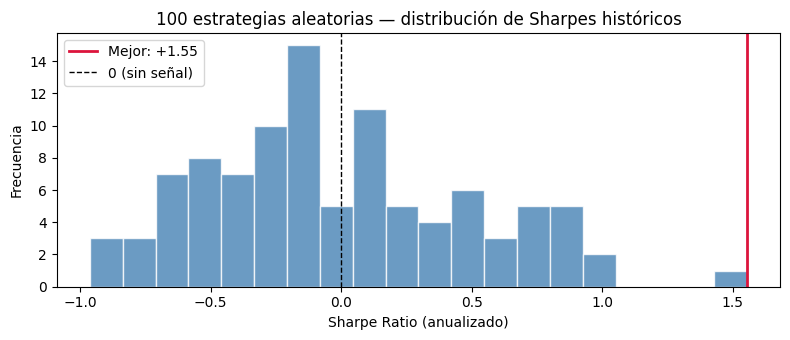

In [2]:
# ── Ejemplo 1.2: El problema del sobreajuste en backtests ──────────────────
#
# Generamos 100 estrategias completamente aleatorias (ruido puro) y observamos
# que la "mejor" de ellas se ve fantástica... aunque ninguna tenga valor real.
#
# Esto ilustra por qué necesitamos el WFPT.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N_DIAS = 1000            # días de datos históricos
N_ESTRATEGIAS = 100      # cuántas "estrategias" probamos
PERIODOS_POR_ANIO = 252  # días bursátiles por año

# Simulamos retornos diarios del mercado (media ~0, vol ~1% diario)
retornos_mercado = rng.normal(loc=0.0004, scale=0.01, size=N_DIAS)

# Cada "estrategia" es simplemente una señal aleatoria (+1 o -1)
# Si el mundo fuera justo, deberían tener Sharpe ~0 en promedio
sharpes = []
for _ in range(N_ESTRATEGIAS):
    señal = rng.choice([-1, 1], size=N_DIAS)
    pnl = señal * retornos_mercado
    sharpe = np.sqrt(PERIODOS_POR_ANIO) * pnl.mean() / pnl.std(ddof=1)
    sharpes.append(sharpe)

sharpes = np.array(sharpes)

print("─" * 50)
print(f"Sharpe promedio de las 100 estrategias: {sharpes.mean():+.3f}")
print(f"Sharpe de la PEOR estrategia:           {sharpes.min():+.3f}")
print(f"Sharpe de la MEJOR estrategia:          {sharpes.max():+.3f}")
print()
print("Si el analista solo reporta la MEJOR estrategia,")
print(f"presenta un Sharpe de {sharpes.max():+.3f} a pesar de que")
print("¡NINGUNA estrategia tenía señal real!")
print("─" * 50)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(sharpes, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(sharpes.max(), color='crimson', linewidth=2, label=f'Mejor: {sharpes.max():+.2f}')
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='0 (sin señal)')
ax.set_xlabel("Sharpe Ratio (anualizado)")
ax.set_ylabel("Frecuencia")
ax.set_title("100 estrategias aleatorias — distribución de Sharpes históricos")
ax.legend()
plt.tight_layout()
plt.show()


**Lección clave:** Un Sharpe de ~1.0 en backtesting **no prueba nada** si probaste
100 estrategias y elegiste la mejor. El WFPT responde: *bajo la hipótesis nula de que
no hay señal, ¿qué tan probable es ver este Sharpe?*


## 1.3 Pruebas de Permutación: La Solución Elegante

### La idea central

Las pruebas de permutación son una forma de construir la distribución nula (el mundo
sin señal) de manera **empírica**, sin asumir ninguna distribución teórica.

La lógica es:
1. Calcula la estadística en los datos reales: $T_{\text{real}}$
2. Destruye cualquier estructura temporal **reordenando aleatoriamente** los datos
3. Calcula la estadística en los datos revueltos: $T_{\text{perm}}$
4. Repite el paso 2-3 muchas veces (Monte Carlo) para construir la **distribución nula**
5. El p-valor es la fracción de veces que $T_{\text{perm}} \geq T_{\text{real}}$

### Ejemplo numérico con 5 datos

Supón que tienes 5 señales de trading y 5 retornos del día siguiente.
Quieres saber si la correlación entre señal y retorno es real o casual.


Estadística REAL (rendimiento promedio): 0.01700

Total de permutaciones posibles: 120
Permutaciones con T >= T_real:   12
p-valor exacto:                  0.1000

→ No hay evidencia suficiente (p >= 0.05) de señal real.
  El resultado podría deberse al azar.



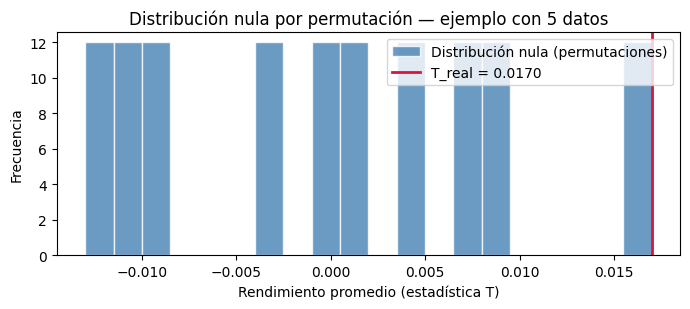

In [3]:
# ── Ejemplo 1.3: Prueba de permutación con 5 datos ─────────────────────────
#
# Señales: +1 (largo) o -1 (corto)
# Retornos: ganancia/pérdida del día siguiente
#
# Pregunta: ¿la correlación entre señal y retorno es real,
# o podría darse por azar con cualquier ordenamiento?

import numpy as np
from itertools import permutations

señales  = np.array([+1, +1, -1, +1, -1])   # señales del modelo
retornos = np.array([+0.02, +0.01, -0.03, +0.015, -0.01])  # retornos observados

# Estadística de prueba: rendimiento promedio de la estrategia
# (señal × retorno, promediado)
def estadistica(s, r):
    return np.mean(s * r)

T_real = estadistica(señales, retornos)
print(f"Estadística REAL (rendimiento promedio): {T_real:.5f}")
print()

# Enumeramos TODAS las permutaciones posibles de los retornos
# (con 5 datos son 5! = 120 permutaciones, manejable a mano)
todas_perms = list(permutations(retornos))
T_perms = np.array([estadistica(señales, list(p)) for p in todas_perms])

# ¿En cuántas permutaciones la estadística es >= T_real?
n_extremos = (T_perms >= T_real).sum()
p_valor = n_extremos / len(T_perms)

print(f"Total de permutaciones posibles: {len(todas_perms)}")
print(f"Permutaciones con T >= T_real:   {n_extremos}")
print(f"p-valor exacto:                  {p_valor:.4f}")
print()
if p_valor < 0.05:
    print("→ Hay evidencia (p < 0.05) de que la señal tiene poder predictivo real.")
else:
    print("→ No hay evidencia suficiente (p >= 0.05) de señal real.")
    print("  El resultado podría deberse al azar.")
print()

# Histograma de la distribución nula
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(T_perms, bins=20, color='steelblue', edgecolor='white', alpha=0.8,
        label='Distribución nula (permutaciones)')
ax.axvline(T_real, color='crimson', linewidth=2, linestyle='-',
           label=f'T_real = {T_real:.4f}')
ax.set_xlabel("Rendimiento promedio (estadística T)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución nula por permutación — ejemplo con 5 datos")
ax.legend()
plt.tight_layout()
plt.show()


**Lo esencial de este ejemplo:**
- La distribución nula la construimos permutando los datos, sin suponer normalidad
  ni ninguna otra distribución.
- Si el p-valor es chico, significa que la correlación observada sería muy rara
  en un mundo sin señal.

En el WFPT haremos exactamente esto, pero con **miles de permutaciones** y con
la complicación adicional de que permutamos **barras OHLC** (precio de apertura,
máximo, mínimo, cierre) para preservar la distribución de los retornos individuales
pero destruir la dependencia temporal.


## 1.4 Validación Walk-Forward: Respetar el Tiempo

### El problema con el train/test split clásico

En machine learning clásico, dividimos datos en entrenamiento y prueba al azar.
Con series de tiempo, esto está **mal**: si entrenas con datos futuros y pruebas
con datos pasados, estás usando información del futuro para predecir el pasado
(lo que se llama **look-ahead bias** o fuga de información hacia adelante).

### La solución: walk-forward

En walk-forward, **el tiempo siempre avanza** y nunca usamos datos futuros para entrenar:

```
Paso 1: Entrena con [Ene-Abr] → Predice [May]
Paso 2: Entrena con [Ene-May] → Predice [Jun]
Paso 3: Entrena con [Ene-Jun] → Predice [Jul]
...
```

La variante que usamos es **anclada** (anchored): la ventana de entrenamiento
**crece** con el tiempo en lugar de deslizarse. Esto imita cómo un fondo real
reentrenaría su modelo en producción.

### Ejemplo con números

| Paso | Datos de entrenamiento | Datos de prueba (OOS) |
|------|------------------------|----------------------|
| 1    | Días 1-1008 (4 años)   | Días 1009-1029       |
| 2    | Días 1-1029            | Días 1030-1050       |
| 3    | Días 1-1050            | Días 1051-1071       |
| ...  | ...                    | ...                  |

Los resultados **OOS (Out-of-Sample)** son los que realmente importan:
el modelo nunca "vio" esos datos cuando fue entrenado.

> **OOS = Out-of-Sample = Fuera de Muestra.** Es el equivalente a "datos de prueba"
> pero respetando el orden temporal.


## 1.5 El Ratio de Sharpe: Midiendo Rendimiento Ajustado por Riesgo

### ¿Qué mide?

El Ratio de Sharpe mide cuánto **rendimiento** obtienes por cada unidad de **riesgo** (volatilidad):

$$\text{Sharpe} = \frac{\bar{r}}{\sigma}$$

donde $\bar{r}$ es el rendimiento promedio y $\sigma$ es la desviación estándar de los rendimientos.

Para anualizarlo (convertir de diario a anual):

$$\text{Sharpe}_{\text{anualizado}} = \sqrt{252} \cdot \frac{\bar{r}_{\text{diario}}}{\sigma_{\text{diario}}}$$

El $\sqrt{252}$ viene de que hay 252 días bursátiles por año.

### Ejemplo numérico

**Estrategia A:**
- Retorno diario promedio: $\bar{r} = +0.001$ (0.1% por día)
- Volatilidad diaria: $\sigma = 0.01$ (1% por día)
- Sharpe diario: $0.001 / 0.01 = 0.10$
- Sharpe anualizado: $\sqrt{252} \times 0.10 \approx 1.59$

**Estrategia B:**
- Retorno diario promedio: $\bar{r} = +0.002$ (0.2% por día)
- Volatilidad diaria: $\sigma = 0.04$ (4% por día)
- Sharpe diario: $0.002 / 0.04 = 0.05$
- Sharpe anualizado: $\sqrt{252} \times 0.05 \approx 0.79$

La Estrategia A tiene **doble rendimiento ajustado por riesgo** aunque gana menos en términos absolutos.

### ¿Qué valores son "buenos"?

| Sharpe Anualizado | Interpretación |
|-------------------|----------------|
| < 0               | Pierde dinero en promedio |
| 0 – 0.5           | Bajo, probablemente no vale la pena |
| 0.5 – 1.0         | Aceptable para una estrategia real |
| 1.0 – 2.0         | Bueno, difícil de lograr consistentemente |
| > 2.0             | Excelente (pero sospechoso en backtesting) |

El Sharpe es nuestra **estadística de prueba** en el WFPT: construiremos
la distribución nula del Sharpe OOS bajo permutación y veremos qué tan extremo
es el Sharpe real del modelo.


           Retorno Diario Promedio  Volatilidad Diaria  Sharpe Anualizado
Estrategia A:  +0.00001              +0.00916           0.013
Estrategia B:  +0.00160              +0.04001           0.634

La Estrategia A tiene mayor Sharpe a pesar de ganar menos en términos absolutos.
Esto se debe a que su riesgo (volatilidad) es mucho menor.


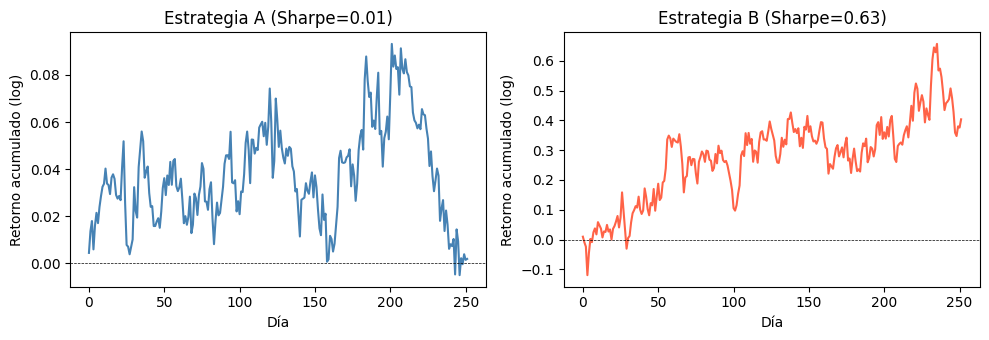

In [4]:
# ── Ejemplo 1.5: Ratio de Sharpe ──────────────────────────────────────────
#
# Comparamos dos estrategias para entender qué mide el Sharpe.

import numpy as np
import matplotlib.pyplot as plt

PERIODOS_POR_ANIO = 252
rng = np.random.default_rng(99)

def simular_estrategia(media_diaria, vol_diaria, n_dias=252, seed=42):
    rng = np.random.default_rng(seed)
    retornos = rng.normal(media_diaria, vol_diaria, size=n_dias)
    sharpe = np.sqrt(PERIODOS_POR_ANIO) * retornos.mean() / retornos.std(ddof=1)
    return retornos, sharpe

ret_A, sh_A = simular_estrategia(media_diaria=0.001,  vol_diaria=0.01, seed=1)
ret_B, sh_B = simular_estrategia(media_diaria=0.002,  vol_diaria=0.04, seed=2)

print("           Retorno Diario Promedio  Volatilidad Diaria  Sharpe Anualizado")
print(f"Estrategia A:  {ret_A.mean():+.5f}              {ret_A.std():+.5f}           {sh_A:.3f}")
print(f"Estrategia B:  {ret_B.mean():+.5f}              {ret_B.std():+.5f}           {sh_B:.3f}")
print()
print("La Estrategia A tiene mayor Sharpe a pesar de ganar menos en términos absolutos.")
print("Esto se debe a que su riesgo (volatilidad) es mucho menor.")

# Curvas de equity acumulado
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, ret, label, color in zip(
    axes,
    [ret_A, ret_B],
    [f"Estrategia A (Sharpe={sh_A:.2f})", f"Estrategia B (Sharpe={sh_B:.2f})"],
    ['steelblue', 'tomato']
):
    equity = np.cumsum(ret)
    ax.plot(equity, color=color, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel("Día")
    ax.set_ylabel("Retorno acumulado (log)")
plt.tight_layout()
plt.show()


## 1.6 XGBoost en 30 Segundos

**XGBoost** (eXtreme Gradient Boosting) es un algoritmo de machine learning basado
en **árboles de decisión con boosting**. Es uno de los modelos más usados en
competencias de Kaggle y en finanzas cuantitativas por su alto rendimiento.

### Idea intuitiva

1. Entrena un árbol de decisión simple (no muy preciso, pero mejor que azar).
2. Identifica los errores del primer árbol.
3. Entrena un segundo árbol para **corregir esos errores**.
4. Repite: cada árbol nuevo corrige los errores del conjunto anterior.
5. La predicción final es la suma de todos los árboles.

### En nuestro contexto

Usamos XGBoost como **clasificador binario**:
- **Entrada (X):** características técnicas del mercado (retornos pasados, volatilidad, RSI...)
- **Salida (y):** +1 si el mercado subió al día siguiente, -1 si bajó

La **señal de trading** es la predicción del modelo: +1 = nos ponemos largos (compramos),
-1 = nos ponemos cortos (vendemos).

### Configuración conservadora

Para evitar sobreajuste, usamos parámetros muy restrictivos:
- Máximo 4 niveles de profundidad por árbol (`max_depth=4`)
- Solo 120 árboles (`n_estimators=120`)
- Sin tuning de hiperparámetros por fold (si ajustáramos parámetros en cada ventana,
  estaríamos inflando artificialmente la tasa de error tipo I)


---
# SECCIÓN 2: Configuración del Entorno

Importamos las librerías necesarias. El código del test vive en el paquete `wfpt/`
que está en el directorio raíz del proyecto. El notebook es solo el "narrativo"
que llama a esas funciones.

**Estructura del paquete `wfpt/`:**
- `data.py` — descarga y construcción de features
- `permutation.py` — permutación Aronson de barras OHLC
- `walkforward.py` — evaluación walk-forward anclada
- `metrics.py` — Sharpe, Profit Factor, CAGR
- `mcpt.py` — orquestador del test Monte Carlo (paralelizado)
- `plotting.py` — gráficas de resultados


In [5]:
import sys
from pathlib import Path

# Asegura que el paquete wfpt/ sea importable
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wfpt import (
    load_sp500, make_features,
    permute_bars,
    walkforward_oos,
    sharpe_annualized, profit_factor, cagr,
    run_wfpt,
    plotting,
)

plotting.use_academic_style()
RNG_SEED = 42  # Semilla maestra — garantiza reproducibilidad total

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
import xgboost, joblib, sklearn
print(f"xgboost {xgboost.__version__}   sklearn {sklearn.__version__}   joblib {joblib.__version__}")


XGBoostError: 
XGBoost Library (libxgboost.so) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ['/home/cord2108/miniconda3/envs/wfpt/lib/python3.11/site-packages/xgboost/lib/libxgboost.so: cannot read file data']


---
# SECCIÓN 3: Datos — S&P 500, Barras Diarias (2005–2024)

## ¿Qué datos usamos?

Descargamos 20 años de datos diarios del **S&P 500** (símbolo `^GSPC`) desde Yahoo Finance.
El S&P 500 es el índice bursátil más importante de Estados Unidos: agrupa las 500
empresas más grandes que cotizan en bolsa.

## ¿Qué es una "barra OHLCV"?

Cada fila de los datos representa **un día de trading**. Por cada día tenemos:

| Columna | Significado |
|---------|-------------|
| **Open (O)** | Precio de apertura (primer precio del día) |
| **High (H)** | Precio más alto del día |
| **Low (L)** | Precio más bajo del día |
| **Close (C)** | Precio de cierre (último precio del día) |
| **Volume (V)** | Número de acciones negociadas |

Estos se llaman **barras OHLCV** (o velas japonesas en análisis técnico).

## ¿Por qué 20 años?

- **Suficientes regímenes:** incluye la Crisis Financiera Global de 2008,
  el mercado alcista de los 2010s, el crash del COVID en 2020, y el ciclo de
  alza de tasas de 2022.
- **Suficiente señal:** con ventanas de entrenamiento de 4 años y pasos de 21 días,
  tenemos ~190 re-entrenamientos del modelo.
- **Manejable en una laptop:** 5,000 barras son computacionalmente ligeras.


In [ ]:
# Descarga los datos del S&P 500 (requiere conexión a internet)
# Si ya los tienes descargados, esta función los usa desde caché de yfinance
df = load_sp500(start="2005-01-01", end="2024-12-31")

print(f"Barras totales: {len(df):,}")
print(f"Período:        {df.index[0].date()}  →  {df.index[-1].date()}")
print(f"Columnas:       {list(df.columns)}")
print()
df.head(8)


## 3.1 Vista Rápida del Precio y los Retornos

Antes de construir el modelo, siempre es buena práctica **explorar los datos visualmente**.

### Log-precio vs precio

Trabajamos con el **log-precio** (logaritmo natural del precio de cierre)
en lugar del precio crudo porque:
1. Los retornos en log-escala son aditivos: $\log(P_t/P_0) = \sum \log(P_i/P_{i-1})$
2. El crecimiento porcentual se ve como una línea recta en log-escala
3. Las propiedades estadísticas de los retornos logarítmicos son más "bien portadas"

### El retorno logarítmico diario

$$r_t = \log\left(\frac{C_t}{C_{t-1}}\right) = \log(C_t) - \log(C_{t-1})$$

Para valores pequeños, esto es aproximadamente el retorno porcentual diario.


In [ ]:
# Calculamos el log-precio y los retornos logarítmicos diarios
log_close = np.log(df["Close"])
log_ret   = log_close.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

# Gráfica superior: log-precio
axes[0].plot(log_close.index, log_close, color=plotting.PALETTE["null"], linewidth=1.0)
axes[0].set_ylabel("log(Precio de Cierre)")
axes[0].set_title("S&P 500 — Log-Precio Diario")

# Gráfica inferior: retornos logarítmicos diarios
axes[1].plot(log_ret.index, log_ret, color=plotting.PALETTE["muted"], linewidth=0.5)
axes[1].set_ylabel("Retorno logarítmico diario")
axes[1].axhline(0, color=plotting.PALETTE["ink"], linewidth=0.4)
axes[1].set_title("Retornos Diarios — nota la heteroscedasticidad (volatilidad cambia con el tiempo)")

plt.tight_layout()
plt.show()

print("─" * 55)
print(f"Retorno medio anualizado:  {log_ret.mean()*252:+.4f}  ({log_ret.mean()*252*100:.2f}%)")
print(f"Volatilidad anualizada:    {log_ret.std()*np.sqrt(252):.4f}  ({log_ret.std()*np.sqrt(252)*100:.2f}%)")
print(f"Sesgo (skewness):          {log_ret.skew():+.3f}")
print(f"Curtosis en exceso:        {log_ret.kurt():+.3f}")
print()
print("Nota: la curtosis positiva (>0) indica 'colas gruesas' —")
print("hay más eventos extremos de lo que predice la distribución normal.")


---
# SECCIÓN 4: Metodología Detallada

Ahora que tenemos los datos y los fundamentos estadísticos, describimos exactamente
cómo funciona el WFPT paso a paso.

## Resumen del Algoritmo

```
1. Cargar datos OHLCV del S&P 500
2. Construir features (variables de entrada para XGBoost)
3. Correr el walk-forward REAL → obtener Sharpe_real (T_real)
4. Para i = 1, 2, ..., 1000:
   a. Permutar las barras OHLCV del período OOS (destruir estructura temporal)
   b. Recalcular features en los datos permutados
   c. Correr el walk-forward completo en los datos permutados → Sharpe_perm[i]
5. p-valor = (1 + #{Sharpe_perm >= Sharpe_real}) / (1 + 1000)
6. Visualizar y concluir
```

El paso 4 es el costoso computacionalmente: corremos **1,000 backtests completos**,
cada uno con ~190 re-entrenamientos de XGBoost. Esto lo paralelizamos con `joblib`.


## 4.1 La Hipótesis Nula — Permutación Aronson

### ¿Qué queremos destruir y qué queremos preservar?

Queremos construir un mundo hipotético donde **no hay estructura temporal**
(no hay momentum, no hay reversión, no hay régimen persistente)
pero donde **la distribución de los retornos individuales es idéntica** a la real.

Si simplemente mezclamos los precios de cierre al azar, la volatilidad y otras
propiedades marginales cambiarían. En cambio, David Aronson propone mezclar
las **componentes internas de cada barra** de forma independiente.

### Descomposición de barras en log-espacio

Cada barra diaria se puede descomponer en 4 componentes aditivos e independientes:

$$\text{gap}_t = \log O_t - \log C_{t-1} \quad \text{(apertura vs. cierre anterior)}$$

$$\text{body}_t = \log C_t - \log O_t \quad \text{(cuerpo de la vela: subió o bajó)}$$

$$\text{high}_t = \log H_t - \log\max(O_t, C_t) \quad \text{(sombra superior, siempre} \geq 0\text{)}$$

$$\text{low}_t = \log\min(O_t, C_t) - \log L_t \quad \text{(sombra inferior, siempre} \geq 0\text{)}$$

### La permutación

1. Tomamos los vectores `gap`, `body`, `high`, `low` de todas las barras OOS
2. **Mezclamos cada vector de forma independiente** con permutaciones aleatorias
3. Reconstruimos el precio OHLC a partir del último Close real (del período de entrenamiento)

**Resultado:**
- ✅ La distribución marginal de gaps, cuerpos y sombras se conserva
- ✅ La volatilidad diaria promedio se conserva
- ❌ La dependencia serial se destruye (no hay autocorrelación, no hay régimen)

Un modelo que realmente captura estructura temporal debería tener Sharpe
**mayor** que el que produciría en estos datos acausales.


## 4.2 La Estadística de Prueba

Usamos el **Sharpe Ratio anualizado** como estadística de prueba:

$$T = \text{Sharpe}_{\text{anualizado}}^{\text{OOS}} = \sqrt{252} \cdot \frac{\bar{r}_{\text{OOS}}}{s_{\text{OOS}}}$$

donde $\bar{r}_{\text{OOS}}$ es la media de los retornos diarios OOS de la estrategia
y $s_{\text{OOS}}$ es su desviación estándar.

El p-valor se calcula con la **corrección +1** (que garantiza que el p-valor es al menos $1/(n+1)$
y evita un p-valor de exactamente 0 que no tendría sentido estadístico):

$$\hat{p} = \frac{1 + \sum_{i=1}^{n} \mathbf{1}\{T_{\text{perm}}^{(i)} \geq T_{\text{real}}\}}{1 + n}$$

### Ejemplo numérico

Supón que corremos $n = 10$ permutaciones y obtenemos estos Sharpes:

```
Sharpes permutados: [0.15, -0.08, 0.22, 0.05, 0.31, 0.12, -0.03, 0.18, 0.25, 0.09]
Sharpe real: 0.20
```

Permutaciones con Sharpe ≥ 0.20: hay 3 (0.22, 0.31, 0.25).

$$\hat{p} = \frac{1 + 3}{1 + 10} = \frac{4}{11} \approx 0.36$$

Con $n = 1000$ permutaciones, la estimación del p-valor es mucho más precisa.


## 4.3 El Walk-Forward Anclado

### ¿Por qué "anclado"?

En la variante **anclada** (anchored), la ventana de entrenamiento siempre empieza
en el día 1 y va creciendo. Esto es diferente de la variante "deslizante" donde
la ventana tiene tamaño fijo.

**Ventaja del anclado:** aprovecha toda la historia disponible para entrenar,
que es lo que haría un fondo en producción.

### Parámetros que usamos

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `train_window` | 252 × 4 = 1,008 días | Mínimo 4 años de entrenamiento inicial |
| `step` | 21 días | Reentrenamos cada mes bursátil (~21 días) |

La primera barra OOS es el día 1,009 (febrero de 2009, habiendo entrenado con 2005-2008).
Hay aproximadamente **190 pasos** de reentrenamiento hasta el final de 2024.


In [ ]:
# Diagrama visual del walk-forward anclado
# (muestra los primeros N pasos para que sea legible)
fig, ax = plt.subplots(figsize=(10, 3.6))
plotting.plot_walkforward_schema(n_total=14, train_window=4, step=2, ax=ax)
ax.set_title(
    "Walk-Forward Anclado — la ventana de entrenamiento crece en cada paso\n"
    "(cada unidad representa ~1 año; los datos reales usan pasos de 21 días)"
)
plt.tight_layout()
plt.show()


## 4.4 ¿A Qué Se Parece una Permutación?

Para hacer tangible la hipótesis nula, graficamos la trayectoria real del S&P 500
junto a una versión permutada. Los primeros 4 años (período de entrenamiento)
se dejan intactos; solo se permuta la ventana OOS.

**Nótese que a simple vista las dos trayectorias se ven "igual de reales".**
La permutación preserva el aspecto estadístico local de las barras
(volatilidad, forma de las velas) pero destruye cualquier tendencia o régimen de largo plazo.


In [ ]:
# Primer índice fuera de muestra (4 años de entrenamiento × 252 días/año)
first_oos_idx = int(252 * 4)
df_perm_demo  = permute_bars(df, start_idx=first_oos_idx, seed=7)

fig, ax = plt.subplots(figsize=(10, 4.0))
plotting.plot_permutation_example(df, df_perm_demo, start_idx=first_oos_idx, ax=ax)
ax.set_title(
    "S&P 500 real vs. una versión permutada\n"
    "La línea vertical separa el período de entrenamiento (izquierda) del OOS (derecha)"
)
plt.tight_layout()
plt.show()


---
# SECCIÓN 5: Ingeniería de Características (Feature Engineering)

## ¿Qué features le damos al modelo?

El modelo XGBoost no "ve" los precios crudos. Le damos variables transformadas
(features) que resumen la historia reciente del mercado. Estas se calculan
en `wfpt/data.py`, función `make_features()`.

### Lista completa de features

| Feature | Descripción | Intuición |
|---------|-------------|-----------|
| `ret_lag_1` | Retorno log de ayer | ¿Hubo momentum/reversión ayer? |
| `ret_lag_2` | Retorno log de hace 2 días | Patrón de 2 días |
| `ret_lag_3` | Retorno log de hace 3 días | Patrón de 3 días |
| `ret_lag_4` | Retorno log de hace 4 días | Patrón de 4 días |
| `ret_lag_5` | Retorno log de hace 5 días | Patrón de semana |
| `vol_5` | Desv. estándar de retornos, ventana 5 días | Volatilidad reciente |
| `vol_21` | Desv. estándar de retornos, ventana 21 días | Volatilidad de mediano plazo |
| `rsi_14` | RSI de 14 períodos | Sobrecompra/sobreventa |
| `ma_ratio` | (MA5 / MA21) - 1 | Cruce de medias móviles |

### Variable objetivo (target)

$$y_t = \text{signo}(r_{t+1}) = \begin{cases} +1 & \text{si el mercado sube mañana} \\ -1 & \text{si el mercado baja mañana} \end{cases}$$

### Retorno para calcular el P&L

El **P&L (Profit & Loss)** de la estrategia en cada día es:

$$\text{PnL}_t = \text{señal}_t \times r_{t+1}$$

donde $\text{señal}_t \in \{-1, +1\}$ es la predicción del modelo y $r_{t+1}$ es el retorno real.

### ¿Por qué estos features y no otros?

Usamos features simples y bien conocidos para evitar sobreajuste.
La restricción más importante: **los mismos features y los mismos hiperparámetros
para todos los folds y para todas las permutaciones**. Si ajustáramos los parámetros
en cada fold, estaríamos inflando la tasa de error tipo I.


In [ ]:
# Construimos los features para los datos reales
# make_features() devuelve:
#   X       — matriz de features (DataFrame con fechas)
#   y       — target: +1 si el mercado subió al día siguiente, -1 si bajó
#   r_real  — retorno logarítmico del día siguiente (para calcular PnL)

X_real, y_real, r_real = make_features(df)

print(f"Filas de features:       {len(X_real):,}")
print(f"Número de features:      {X_real.shape[1]}")
print(f"Features:                {list(X_real.columns)}")
print()
print(f"Primera barra OOS:       {X_real.index[252*4].date()}")
print(f"Barras OOS estimadas:    {len(X_real) - 252*4:,}")
print()
print("Primeras 5 filas de la matriz de features:")
print(X_real.head().to_string())
print()
print("Distribución del target (y):")
print(y_real.value_counts().rename({1: 'Subió (+1)', -1: 'Bajó (-1)'}))
print()
pct_sube = (y_real == 1).mean() * 100
print(f"El mercado sube el {pct_sube:.1f}% de los días (sesgo alcista leve)")


**Parámetros clave del walk-forward:**


In [ ]:
TRAIN_WINDOW = 252 * 4  # 4 años de entrenamiento inicial
STEP         = 21       # reentrenamos cada mes bursátil (~21 días)

print(f"Ventana de entrenamiento inicial: {TRAIN_WINDOW} días = {TRAIN_WINDOW/252:.1f} años")
print(f"Paso entre re-entrenamientos:     {STEP} días (~1 mes bursátil)")
print(f"Número aproximado de re-entrenos: {(len(X_real)-TRAIN_WINDOW)//STEP}")


---
# SECCIÓN 6: La Estrategia Real — Línea Base

## ¿Qué hacemos aquí?

Corremos el **walk-forward completo** con los **datos reales** (sin permutar).
El resultado es la serie temporal de retornos OOS de la estrategia, con la que
calculamos el Sharpe, el Profit Factor y el CAGR reales.

Este es nuestro **$T_{\text{real}}$**: la estadística que intentaremos poner en perspectiva
comparándola contra la distribución nula.

## Métricas que calcularemos

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Sharpe anualizado** | $\sqrt{252} \cdot \bar{r}/s$ | Rendimiento ajustado por riesgo |
| **Profit Factor** | $\sum r^+ / \sum |r^-|$ | Cuánto ganas por cada peso perdido |
| **CAGR** | $\exp(\bar{r}_{\log} \cdot 252) - 1$ | Tasa de crecimiento anual compuesto |

> **Nota:** Todos los retornos son log-retornos y **no incluyen costos de transacción**
> (comisiones, deslizamiento, costo de posición corta). Un Sharpe de ~0.5 aquí
> probablemente sería negativo en producción real.


In [ ]:
%%time
# Corremos el walk-forward en los datos reales
# Esto tarda ~1-2 minutos dependiendo del hardware

oos_real   = walkforward_oos(
    X_real, y_real, r_real,
    train_window=TRAIN_WINDOW,
    step=STEP,
)
real_sharpe = sharpe_annualized(oos_real)
real_pf     = profit_factor(oos_real)
real_cagr   = cagr(oos_real)

print("─" * 40)
print(f"Barras OOS producidas: {len(oos_real):,}")
print(f"Período OOS:           {oos_real.index[0].date()} → {oos_real.index[-1].date()}")
print()
print(f"Sharpe anualizado:     {real_sharpe:+.3f}")
print(f"Profit Factor:         {real_pf:.3f}  (>1 = estrategia ganadora en bruto)")
print(f"CAGR:                  {real_cagr*100:+.2f}%")
print("─" * 40)
print()
print("Interpretación preliminar:")
if real_sharpe > 0.5:
    print(f"  El Sharpe de {real_sharpe:.3f} parece prometedor, pero esto NO")
    print("  prueba que sea estadísticamente significativo.")
    print("  El test de permutación (sección 7) nos dirá si es real o suerte.")
else:
    print(f"  El Sharpe de {real_sharpe:.3f} es modesto. Necesitamos el test de")
    print("  permutación para saber si es estadísticamente significativo.")


In [ ]:
# Visualizamos la curva de equity OOS antes de correr el test
fig, ax = plt.subplots(figsize=(10, 4.0))
eq_real = oos_real.cumsum()
ax.plot(eq_real.index, eq_real, color=plotting.PALETTE["real"], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.fill_between(eq_real.index, 0, eq_real,
                where=(eq_real >= 0), alpha=0.15, color='green')
ax.fill_between(eq_real.index, 0, eq_real,
                where=(eq_real < 0), alpha=0.15, color='red')
ax.set_ylabel("Retorno acumulado OOS (log)")
ax.set_title(
    f"Curva de equity OOS — estrategia real\n"
    f"Sharpe: {real_sharpe:+.3f} | CAGR: {real_cagr*100:+.1f}% | PF: {real_pf:.3f}"
)
plt.tight_layout()
plt.show()


---
# SECCIÓN 7: Test de Permutación Monte Carlo — Paralelo

## ¿Qué hacemos aquí?

Construimos la **distribución nula** del Sharpe OOS mediante $n = 1000$ permutaciones.

Cada una de las 1000 iteraciones hace lo siguiente:
1. **Permuta** las barras OHLCV desde el inicio del período OOS
2. **Recalcula** los features en los datos permutados
3. **Corre el walk-forward completo** (con re-entrenamiento en cada paso)
4. **Devuelve** el Sharpe OOS de esa permutación

Al final tenemos 1000 valores de Sharpe que representan "qué tan bien podría
hacer el modelo si no hubiera señal real en el mercado".

## Paralelización

Cada permutación es **completamente independiente** de las demás (solo necesita
el DataFrame original y su semilla aleatoria). Esto permite paralelizar trivialmente
usando `joblib.Parallel` con múltiples núcleos de CPU.

**Reproducibilidad:** usamos `numpy.random.SeedSequence` para derivar semillas
hijas deterministas de la semilla maestra. El resultado es bit-por-bit idéntico
sin importar cuántos workers se usen.

## Costo computacional

Un solo walk-forward tarda ~20-40 segundos en hardware típico.
Con 8 núcleos y 1000 permutaciones:

$$t_{\text{total}} \approx \frac{1000 \times 30\text{ s}}{8 \text{ núcleos}} \approx 62 \text{ minutos}$$

> Si tienes prisa, reduce `N_PERMUTATIONS` a 100 o 200.
> El p-valor será menos preciso pero dará la misma conclusión cualitativa.


In [ ]:
N_PERMUTATIONS = 1000   # reduce a 100 o 200 para una corrida rápida
N_JOBS         = 8      # número de núcleos de CPU a usar (-1 = todos)

print(f"Configuración del test:")
print(f"  Permutaciones:     {N_PERMUTATIONS:,}")
print(f"  Workers paralelos: {N_JOBS}")
print(f"  Semilla maestra:   {RNG_SEED}")
print()
print(f"Tiempo estimado con {N_JOBS} núcleos: ~{N_PERMUTATIONS*30/N_JOBS/60:.0f} minutos")
print("(varía según el hardware)")


In [ ]:
# ── Corremos el test completo ────────────────────────────────────────────────
#
# run_wfpt() hace todo el trabajo:
#   1. Corre el walk-forward real (ya lo hicimos arriba, pero aquí lo repite)
#   2. Genera N_PERMUTATIONS permutaciones y corre el WF en cada una (en paralelo)
#   3. Calcula el p-valor con la corrección +1
#   4. Devuelve un objeto WFPTResult con todos los resultados

result = run_wfpt(
    df,
    n_permutations=N_PERMUTATIONS,
    train_window=TRAIN_WINDOW,
    step=STEP,
    n_jobs=N_JOBS,
    master_seed=RNG_SEED,
    progress=True,
)

print(f"\nTiempo total: {result.elapsed_seconds:.1f}s "
      f"({result.elapsed_seconds/N_PERMUTATIONS*1000:.0f} ms / permutación)")


---
# SECCIÓN 8: Resultados

## Tabla resumen

El objeto `result` contiene todos los datos del test. Empezamos con una tabla
de resumen que muestra las métricas más importantes.


In [ ]:
summary = result.summary()
print(summary.to_string())
print()

# Explicación de cada fila
print("─" * 60)
print("Explicación de la tabla:")
print(f"  real_sharpe:     Sharpe OOS de la estrategia REAL: {result.real_sharpe:.4f}")
print(f"  null_mean:       Media de los Sharpes de las {N_PERMUTATIONS} permutaciones")
print(f"  null_std:        Desv. estándar de la distribución nula")
print(f"  null_q05/q95:    Percentiles 5% y 95% de la distribución nula")
print(f"  n_perm_geq_real: Permutaciones con Sharpe >= Sharpe_real")
print(f"  p_valor:         p = (1 + n_perm_geq_real) / (1 + {N_PERMUTATIONS})")
print()

p = result.p_value
if p < 0.01:
    nivel = "muy fuerte (p < 0.01)"
elif p < 0.05:
    nivel = "significativa (p < 0.05)"
elif p < 0.10:
    nivel = "marginal (0.05 ≤ p < 0.10)"
else:
    nivel = "no significativa (p ≥ 0.10)"

print(f"CONCLUSIÓN: Evidencia {nivel}")
print(f"           p-valor = {p:.4f}")


## 8.1 Distribución Nula del Sharpe Ratio

Este es el gráfico central del test. Muestra:

- **Histograma azul:** la distribución de los Sharpes OOS de las 1,000 permutaciones.
  Cada barra representa "qué tan frecuente fue ese nivel de Sharpe bajo la hipótesis nula."
- **Línea roja vertical:** el Sharpe OOS de la estrategia **real**.

### ¿Cómo leer este gráfico?

- Si la línea roja está **muy a la derecha** del histograma: el Sharpe real es inusualmente
  alto bajo la hipótesis nula → hay evidencia de señal real → p-valor chico.
- Si la línea roja está **dentro o a la izquierda** del histograma: el Sharpe real
  es perfectamente compatible con el azar → no hay evidencia de señal → p-valor grande.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.6))
plotting.plot_null_distribution(
    real_value=result.real_sharpe,
    perm_values=result.perm_sharpes,
    p_value=result.p_value,
    metric_name="Sharpe Ratio (anualizado)",
    bins=40,
    ax=ax,
)
ax.set_title(
    f"Distribución Nula del Sharpe — {N_PERMUTATIONS:,} permutaciones Aronson\n"
    f"Sharpe real = {result.real_sharpe:.3f}  |  p-valor = {result.p_value:.4f}"
)
plt.tight_layout()
plt.show()


## 8.2 Curvas de Equity: Real vs. Envolvente de Permutaciones

### La banda de referencia

La zona sombreada muestra la banda entre el percentil 5% y el 95% de las
1,000 curvas de equity permutadas. La línea punteada es la mediana.

### ¿Cómo interpretar?

- Si la curva real vive **consistentemente por encima** del borde superior de la banda:
  la estrategia es estadísticamente superior al azar.
- Si la curva real está **dentro de la banda**: el desempeño es indistinguible del azar.
- Si la curva real cae **por debajo** de la banda: el modelo está activamente destruyendo valor.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plotting.plot_equity_bands(
    real_returns=result.real_oos_returns,
    perm_returns=result.perm_oos_returns,
    quantiles=(0.05, 0.95),
    ax=ax,
)
ax.set_title(
    f"Curva de Equity OOS — Real vs. Envolvente de {N_PERMUTATIONS:,} Permutaciones\n"
    "Banda sombreada: [percentil 5%, 95%] de las permutaciones"
)
plt.tight_layout()
plt.show()


## 8.3 Todas las Curvas de Permutación

Este gráfico muestra todas las 1,000 curvas de equity permutadas superpuestas
(en gris translúcido) junto con la estrategia real (en rojo/azul destacado).
La "nube" de curvas grises representa la distribución nula completa en el tiempo.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.0))

# Graficamos todas las curvas permutadas (finas y transparentes)
for perm_ret in result.perm_oos_returns:
    eq = perm_ret.reindex(result.real_oos_returns.index).cumsum()
    ax.plot(eq.index, eq, color=plotting.PALETTE["null"],
            linewidth=0.4, alpha=0.06)

# La estrategia real encima
real_eq = result.real_oos_returns.cumsum()
ax.plot(real_eq.index, real_eq, color=plotting.PALETTE["real"],
        linewidth=2.0, label="Estrategia real", zorder=10)

ax.axhline(0, color=plotting.PALETTE["muted"], linewidth=0.6, linestyle='--')
ax.set_ylabel("Retorno acumulado OOS (log)")
ax.set_title(
    f"Estrategia real vs. {len(result.perm_oos_returns):,} curvas de equity permutadas\n"
    "Las curvas grises son el mundo sin señal (hipótesis nula)"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 8.4 Intervalo de Confianza Bootstrap para el p-valor

### El p-valor también tiene incertidumbre

El p-valor que calculamos es una **estimación** basada en $n$ permutaciones.
Si corriéramos el test otra vez con distinta semilla, obtendríamos un p-valor
ligeramente diferente. ¿Cuánto varía?

Para responder esto, usamos **bootstrap**: tomamos los 1,000 Sharpes permutados,
los remuestreamos **con reemplazo** y recalculamos el p-valor en cada resample.
Después de 2,000 re-muestras, tenemos la distribución de posibles p-valores.

El **intervalo de confianza al 95%** nos dice: *si el test es estable, los extremos
del intervalo deberían llevar a la misma conclusión que el p-valor puntual.*

### Interpretación

- Si el intervalo entero está **por debajo de 0.05**: conclusión robusta (hay señal).
- Si el intervalo entero está **por encima de 0.05**: conclusión robusta (no hay señal).
- Si el intervalo **cruza 0.05**: la conclusión es sensible al ruido Monte Carlo
  → considerar más permutaciones.


In [ ]:
def bootstrap_p_ci(perm_sharpes, real_sharpe, n_boot=2000, alpha=0.05, seed=0):
    """IC Bootstrap para el p-valor del WFPT."""
    rng = np.random.default_rng(seed)
    n = len(perm_sharpes)
    ps = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = perm_sharpes[idx]
        ps[b] = (1 + (sample >= real_sharpe).sum()) / (1 + n)
    return ps.mean(), np.quantile(ps, alpha/2), np.quantile(ps, 1 - alpha/2)

p_mean, p_lo, p_hi = bootstrap_p_ci(result.perm_sharpes, result.real_sharpe)
print(f"p-valor (puntual):         {result.p_value:.4f}")
print(f"p-valor (media bootstrap): {p_mean:.4f}")
print(f"IC 95% bootstrap:          [{p_lo:.4f},  {p_hi:.4f}]")
print()

if p_hi < 0.05:
    robustez = "ROBUSTO — incluso el límite superior del IC está bajo 0.05"
elif p_lo > 0.05:
    robustez = "ROBUSTO — incluso el límite inferior del IC está sobre 0.05"
else:
    robustez = "FRÁGIL — el IC cruza 0.05, considera más permutaciones"

print(f"Robustez de la conclusión: {robustez}")


---
# SECCIÓN 9: Discusión e Interpretación

## ¿Qué significa el p-valor en este contexto?

El p-valor responde exactamente a esta pregunta:

> *"Si el mercado no tuviera ninguna estructura temporal explotable
> (i.e., las barras fueran intercambiables), ¿qué probabilidad habría
> de ver un Sharpe OOS tan alto o más alto que el observado?"*

- **p-valor = 0.05:** solo 5% de las trayectorias acausales son tan buenas.
  Hay evidencia de que el modelo captura algo real.
- **p-valor = 0.50:** la mitad de las trayectorias aleatorias son tan buenas.
  El modelo es indistinguible del azar.

## Limitaciones del test (honestidad intelectual)

### 1. Un solo estadístico de prueba
Usamos el Sharpe. Una estrategia con Sharpe bajo pero cola derecha gruesa
(muchas ganancias pequeñas y pocas pérdidas grandes) podría pasar una prueba
de Profit Factor y fallar esta. Ningún estadístico captura todo.

### 2. Mismo modelo, mismos parámetros
El test aísla la pregunta de extracción de señal pero **no controla los grados
de libertad del analista** en la selección de features o hiperparámetros.
Para eso existen el Reality Check de White (2000) o el SPA de Hansen (2005).

### 3. Sin fricciones
No incluimos comisiones, deslizamiento ni costo de financiamiento en corto.
Un Sharpe OOS de 1.0 aquí probablemente sería 0.3-0.5 en producción real.

### 4. La permutación destruye agrupamiento de volatilidad
El modelo podría beneficiarse de volatilidad agrupada (GARCH-like).
La permutación Aronson también destruye ese agrupamiento, haciendo la prueba
más estricta que la realidad para estrategias basadas en volatilidad.
El **bootstrap por bloques** sería más conservador, pero computacionalmente
mucho más costoso.

### 5. La permutación mantiene la sección de entrenamiento intacta
El modelo se entrena en datos reales (2005-2009). La señal en el período
de entrenamiento no se evalúa — solo importa el OOS.

## ¿Qué haría un analista en la práctica?

1. Obtener p < 0.05 en el WFPT → condición necesaria pero no suficiente
2. Verificar que el intervalo bootstrap no cruce 0.05
3. Repetir el test con diferentes ventanas temporales (¿es la señal estable?)
4. Incluir costos de transacción realistas
5. Correr el test con un estadístico alternativo (Profit Factor, Calmar ratio)
6. Validar fuera de muestra en **datos que nunca tocaste** (test set final)


---
# SECCIÓN 10: Reproducibilidad

Un análisis científico debe ser **reproducible**: otra persona (o tú mismo
en seis meses) debe poder obtener exactamente los mismos números.

## Mecanismo de reproducibilidad

| Elemento | Valor | Propósito |
|----------|-------|-----------|
| `RNG_SEED = 42` | Semilla maestra | Punto de partida para todo el aleatorismo |
| `SeedSequence` | Derivación determinista | Genera semillas hijas independientes para cada permutación |
| Parámetros XGBoost fijos | Ver `wfpt/model.py` | Mismos hiperparámetros en todos los folds y permutaciones |
| `n_jobs=-1` vs `n_jobs=1` | Mismo resultado | Las semillas hijas son independientes del número de workers |

## Para regenerar desde cero

1. Reinicia el kernel de Jupyter (`Kernel → Restart & Run All`)
2. Asegúrate de usar el mismo entorno conda: `conda activate wfpt`
3. Los resultados deben ser bit-por-bit idénticos

## Entorno de software

```
numpy   1.26.4
pandas  3.0.x
xgboost 2.1.x
sklearn 1.5.x
joblib  1.5.x
```

## Lectura adicional

- Aronson, D. (2007). *Evidence-Based Technical Analysis*. Wiley.
- White, H. (2000). "A Reality Check for Data Snooping." *Econometrica*, 68(5).
- Hansen, P. (2005). "A Test for Superior Predictive Ability." *JBES*, 23(4).
- Bailey et al. (2014). "The Deflated Sharpe Ratio." *JOIM*.
